In [1]:
import matplotlib.pyplot as plt
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.layers.embeddings import GridEmbedding2D

In [2]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=20,
    batch_size=4,
    test_resolutions=[16, 32],
    n_tests=[10, 10],
    test_batch_sizes=[4, 2],
)

train_dataset = train_loader.dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 


In [3]:
for res, test_loader in test_loaders.items():
    print(f"Resolution: {res}")
    # Get first batch
    batch = next(iter(test_loader))
    x = batch["x"]  # Input
    y = batch["y"]  # Output

    print(f"Testing samples for resolution {res} have shape {x.shape[1:]}")


data = train_dataset[0]
x = data["x"]
y = data["y"]

print(f"Training samples have shape {x.shape[1:]}")

# Which sample to view
index = 0

data = train_dataset[index]
data = data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]


Resolution: 16
Testing samples for resolution 16 have shape torch.Size([1, 16, 16])
Resolution: 32
Testing samples for resolution 32 have shape torch.Size([1, 32, 32])
Training samples have shape torch.Size([16, 16])


/tmp/ipykernel_19082/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


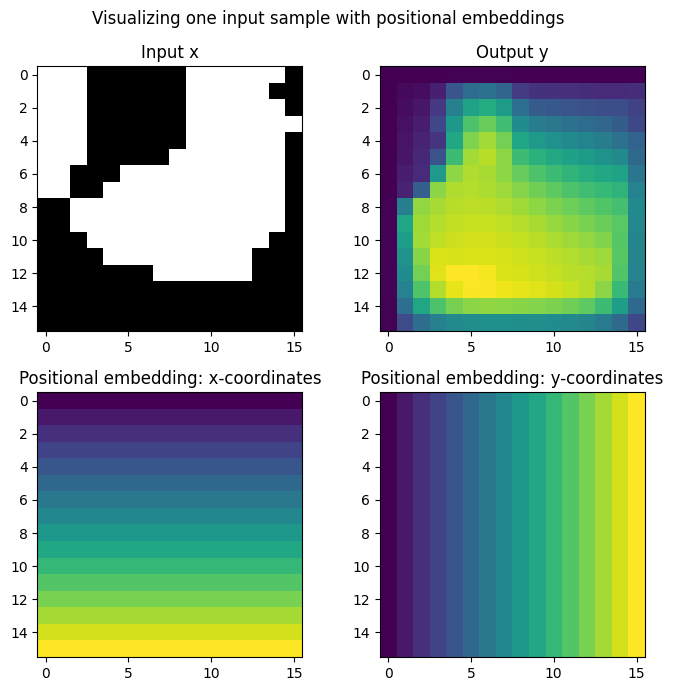

In [4]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()